# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 26     |  |
| :-------------|:-------------|
| Bob Villerius | 6483895 |
| Adam Echant Hamdioui| 6563031 |
| Dexter Mourik| 6270433 |

In [13]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Bob Villerius', 'Adam Echant Hamdioui']

## Opdracht 1: Planning.

| Planning Groep: 26     |Tijdstip / Tijdspanne  |
|---|---|
| Kalibratie af | 11:20 |
| Meetopstelling getest | 12:00 |
| Pauze 1 | 12:30-13:45 |
| Algoritmes bedacht | 13:45 |
| Eerste poging | 14:30 |
| Iteratie 1 | 15:15 |
| Algoritme af en controleren door TA| 16:00 |


## Opdracht 2: Import libs.

In [14]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [26]
<img src="kalibratie.jpg" width="400">

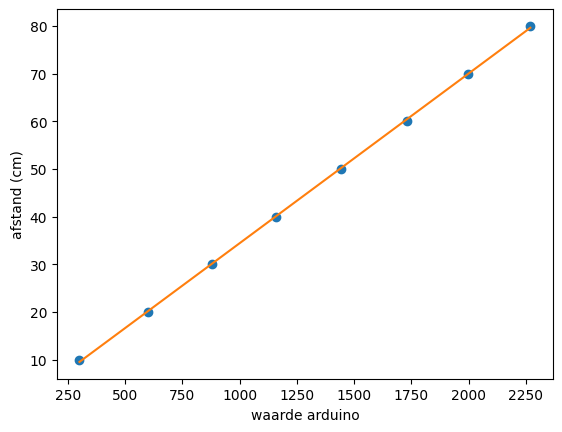

De kalibratieformule is: Afstand = 0.036 * waarde_arduino + -1.173


In [15]:
# verwerk hier jullie kalibratiemetingen 
from scipy.optimize import curve_fit

afstand_kalibratie=np.array([10,20, 30, 40, 50, 60, 70, 80]) #cm
waarde_arduino_kalibratie=np.array([301, 600, 880, 1160, 1441, 1730, 1997, 2270])
# Lineair verband

def kalibratie(x, a, b):
    return a*x + b

val, cov=curve_fit(kalibratie, waarde_arduino_kalibratie, afstand_kalibratie)

plt.figure()
plt.plot(waarde_arduino_kalibratie, afstand_kalibratie, 'o')
plt.plot(waarde_arduino_kalibratie, kalibratie(waarde_arduino_kalibratie, *val), label='fit: a=%5.3f, b=%5.3f' % tuple(val))
plt.xlabel('waarde arduino')
plt.ylabel('afstand (cm)')
plt.show()
print(f"De kalibratieformule is: Afstand = {val[0]:.3f} * waarde_arduino + {val[1]:.3f}")

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  40   0  30  40.50
1   0  30   0  20  40.80
2  40   0  30   0  40.05
3  30   0  20   0  41.00


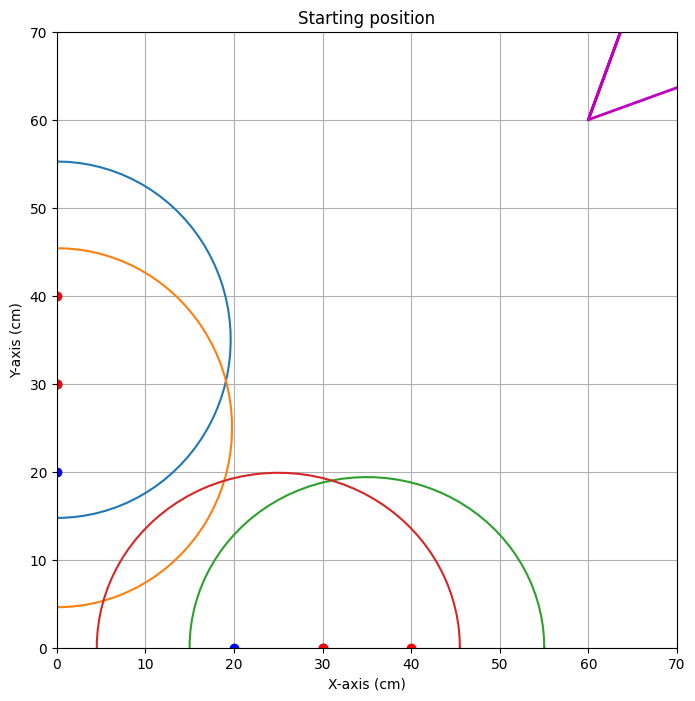


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=101.367


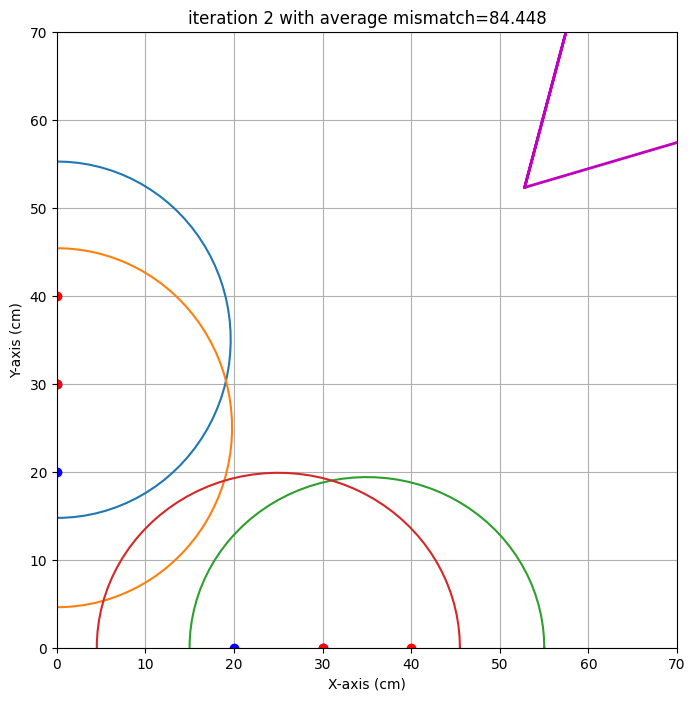

end iteration 2 with average mismatch=84.448


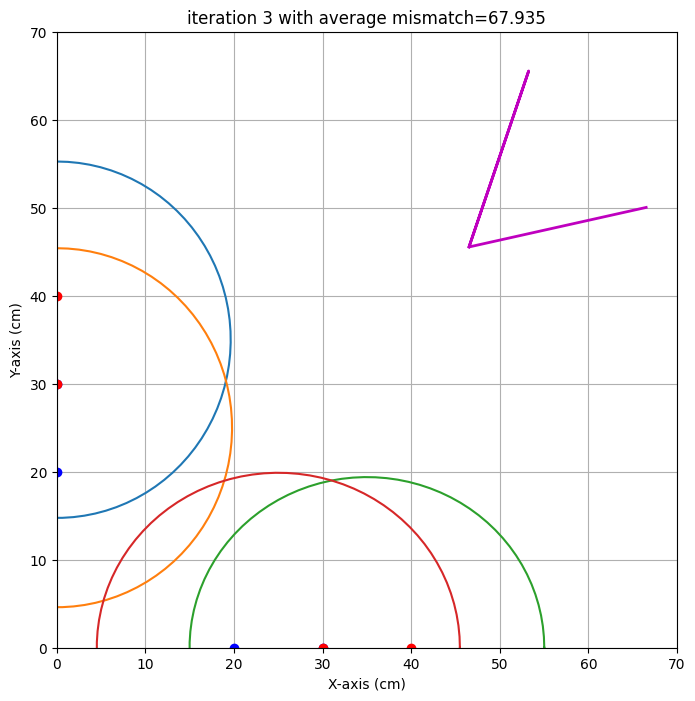

end iteration 3 with average mismatch=67.935


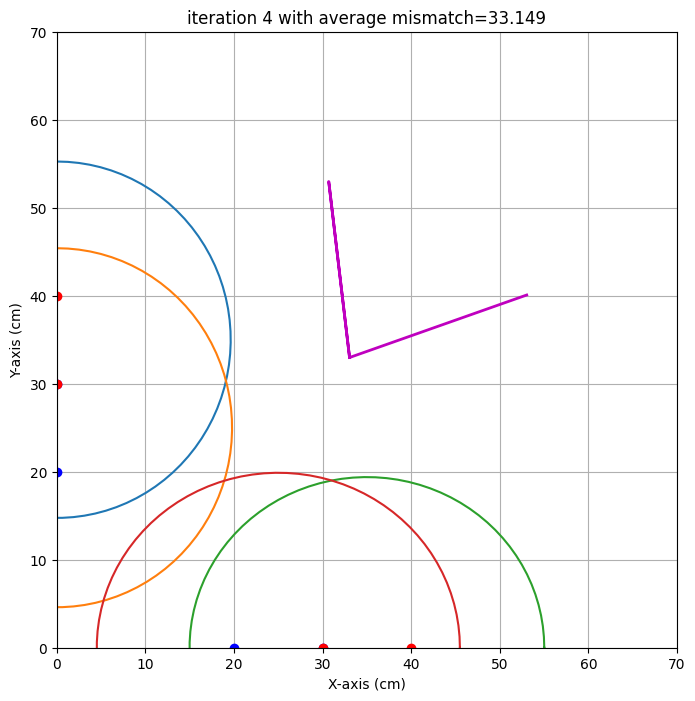

end iteration 4 with average mismatch=33.149


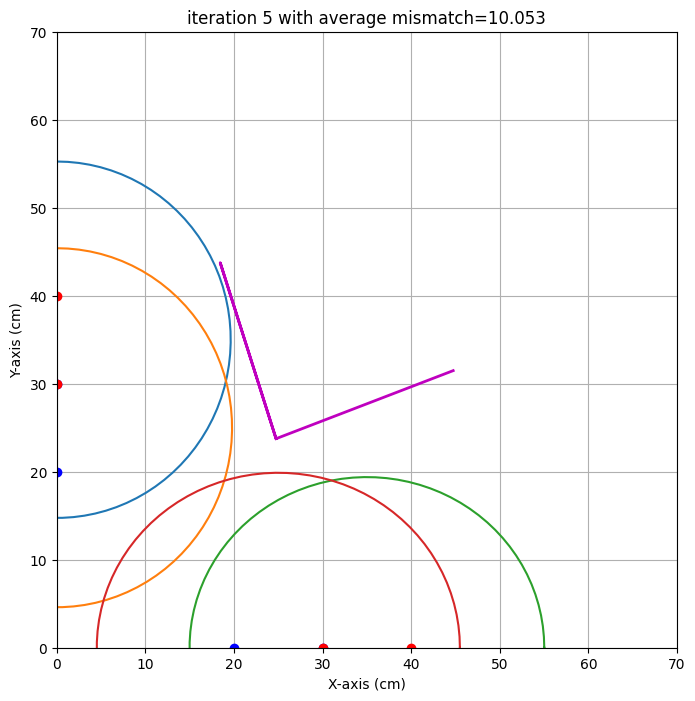

end iteration 5 with average mismatch=10.053


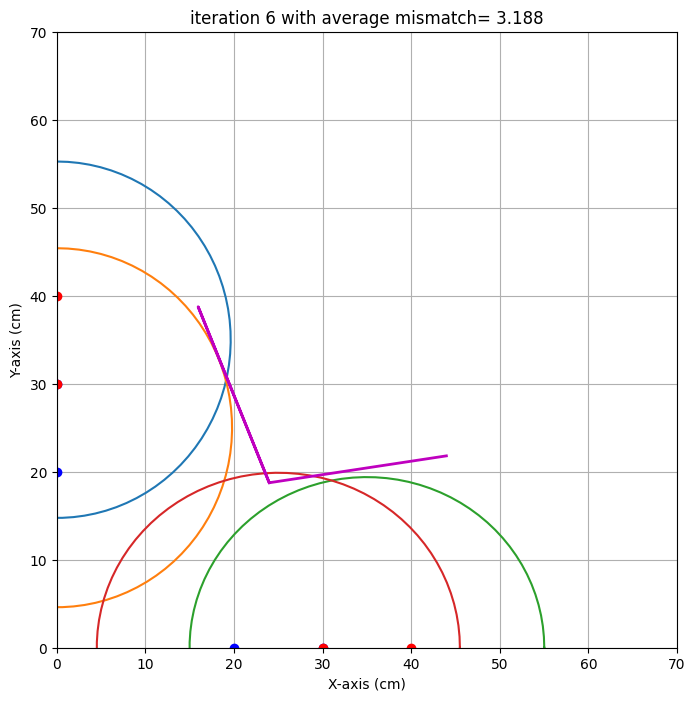

end iteration 6 with average mismatch= 3.188


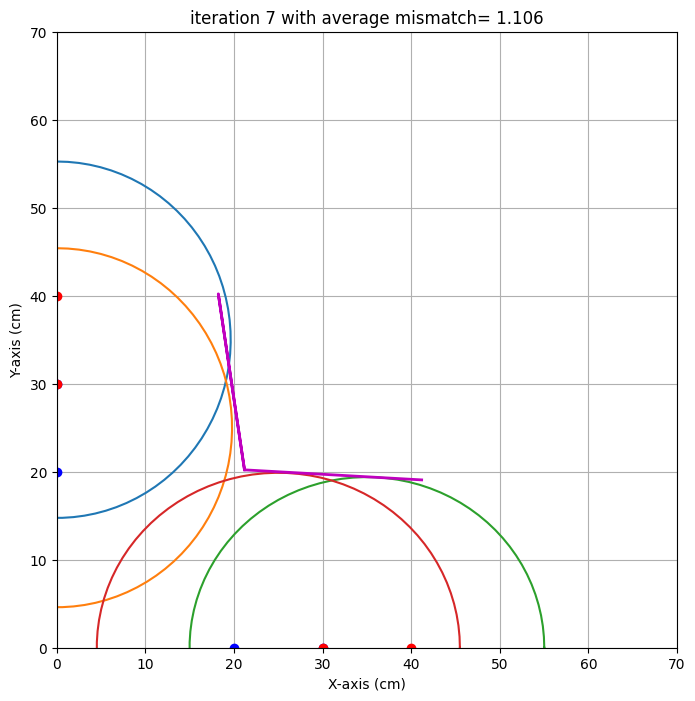

end iteration 7 with average mismatch= 1.106


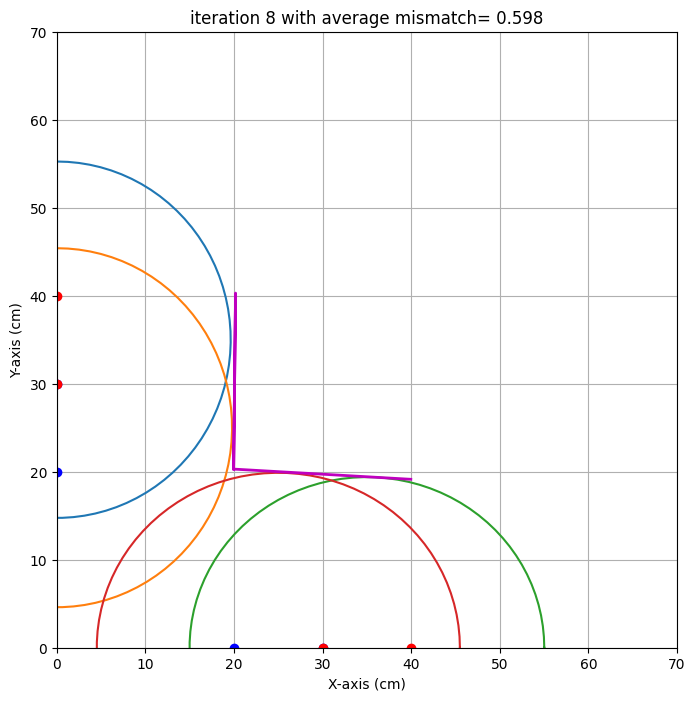

end iteration 8 with average mismatch= 0.598
end iteration 9 with average mismatch= 0.556


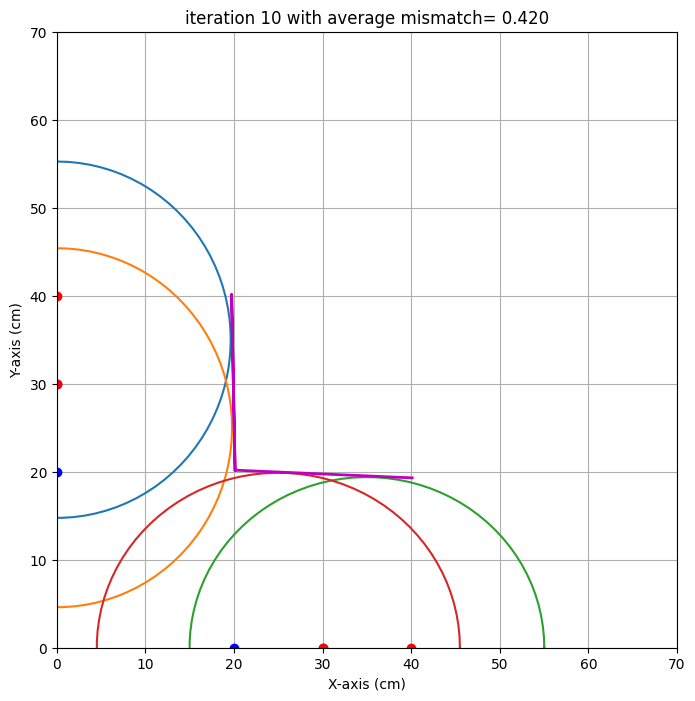

end iteration 10 with average mismatch= 0.420


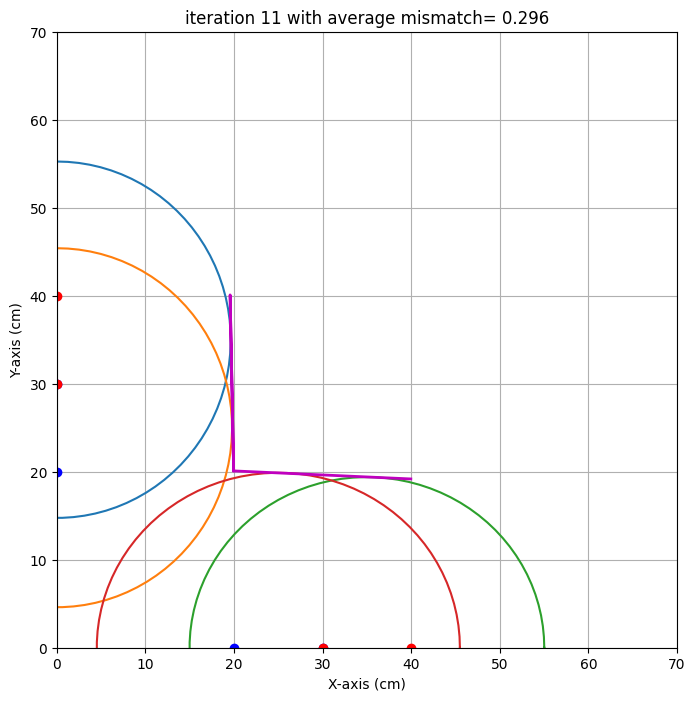

end iteration 11 with average mismatch= 0.296


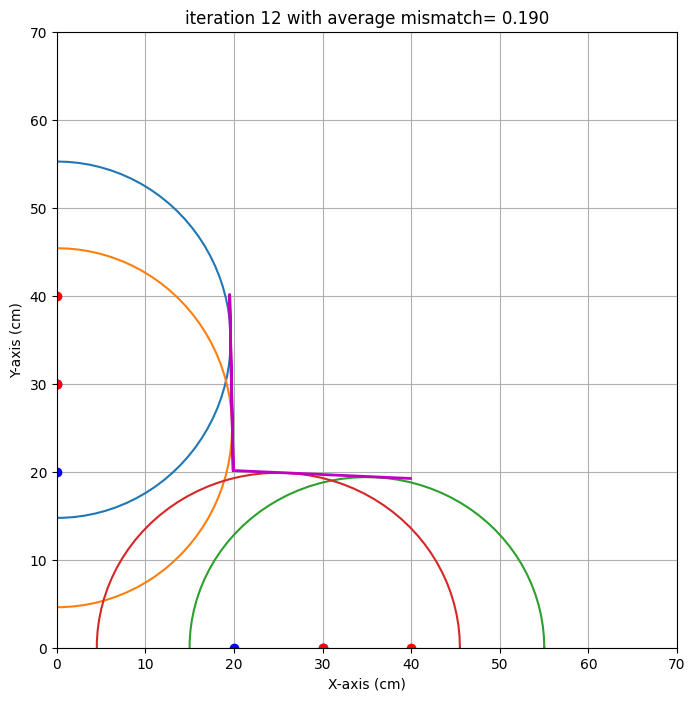

end iteration 12 with average mismatch= 0.190
end iteration 13 with average mismatch= 0.187
end iteration 14 with average mismatch= 0.187
end iteration 15 with average mismatch= 0.187
end iteration 16 with average mismatch= 0.187
end iteration 17 with average mismatch= 0.187
end iteration 18 with average mismatch= 0.187
end iteration 19 with average mismatch= 0.187
end iteration 20 with average mismatch= 0.187
end iteration 21 with average mismatch= 0.187
end iteration 22 with average mismatch= 0.187
end iteration 23 with average mismatch= 0.187
end iteration 24 with average mismatch= 0.187
end iteration 25 with average mismatch= 0.187
end iteration 26 with average mismatch= 0.187
end iteration 27 with average mismatch= 0.187
end iteration 28 with average mismatch= 0.187
end iteration 29 with average mismatch= 0.187
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch

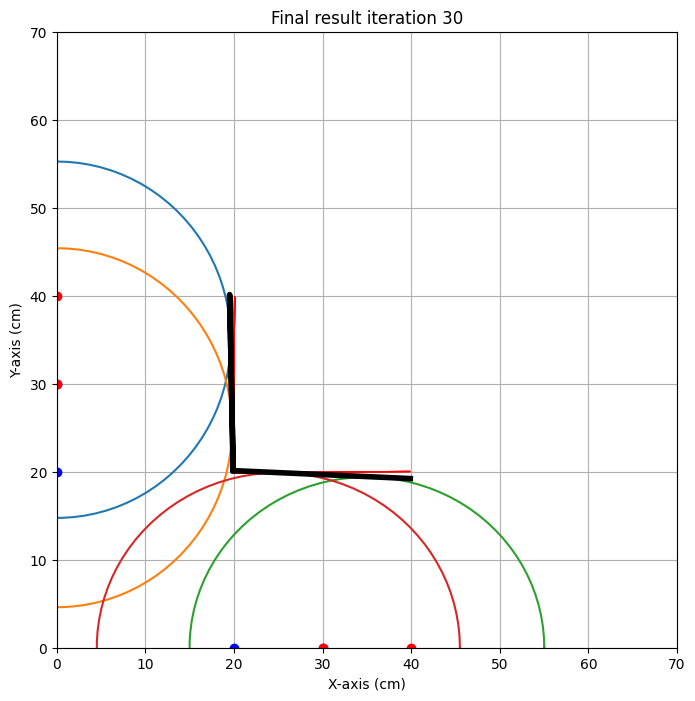

In [16]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,40.5],
    [0,30,0,20,40.8],
    #[0,10,0,20,49.5],
    [40,0,30,0,40.05],
    [30,0,20,0,41.0],
    #[10,0,20,0,47],
    #[10,0,0,10,]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [17]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 19.9 cm met een standaardafwijking van 0.1 cm 
y0: 20.1 cm met een standaardafwijking van 0.3 cm 
alpha: -2.6 graden met een standaardafwijking van 3.1 graad 
beta: -1.1 graden met een standaardafwijking van 1.9 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Bob Villerius]
Voeg een foto in van het algoritme van het eerste groepslid
<img src="algorBob.jpeg" width="400">

#### algoritme [Adam Echant Hamdioui]
Voeg een foto in van het algoritme van het tweede groepslid
<img src="algorAdam1.jpeg" width="400">
<img src="algorAdam2.jpeg" width="400">

#### algoritme [Dexter Mourik]
Voeg een foto in van het algoritme van het derde groepslid
<img src="algorDexter.jpeg" width="400">

In [18]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [19]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':29,  #zelf aanvullen,
           'y0':39,#zelf aanvullen,
           'alpha' :-11, #zelf aanvullen,
           'beta' : -19#zelf aanvullen},    
}       

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Bob Villerius' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
   #[20,0,40,0,x],
   [0,50,0,70,70.2], 
   [0,45,0,65,67.12],
   [20,0,40,0, 76.95],
   [25,0,45,0, 75]
    ])
,
       'Adam Echant Hamdioui' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[0,70,0,50,x],
   [70,0,50,0,70],
   [0,50,0,30,72.6],
   #[50,0,30,0,x],
   [0,40,0,20, 77.34]
   #[0,40,0,20,x]
    ])}

## Opdracht 7: Evaluatie.

Bob Villerius
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  50   0  70  70.20
1   0  45   0  65  67.12
2  20   0  40   0  76.95
3  25   0  45   0  75.00


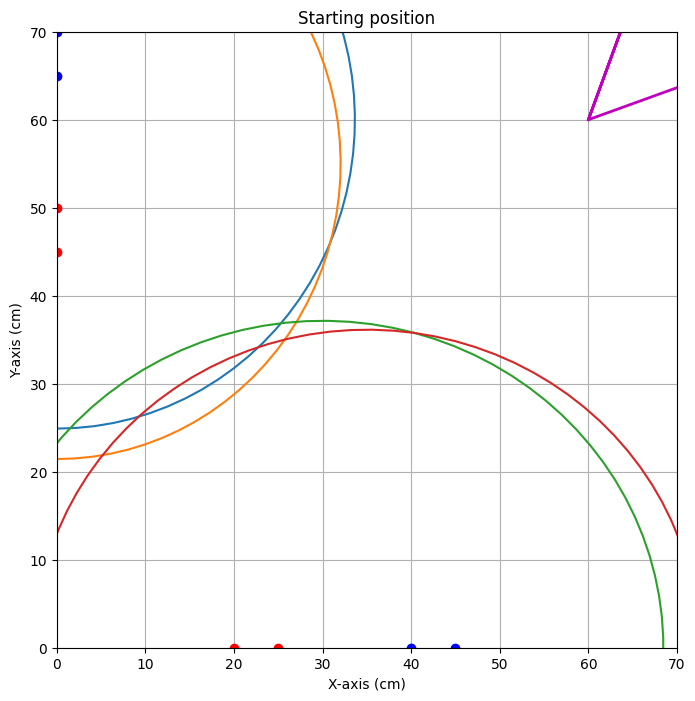


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=60.666


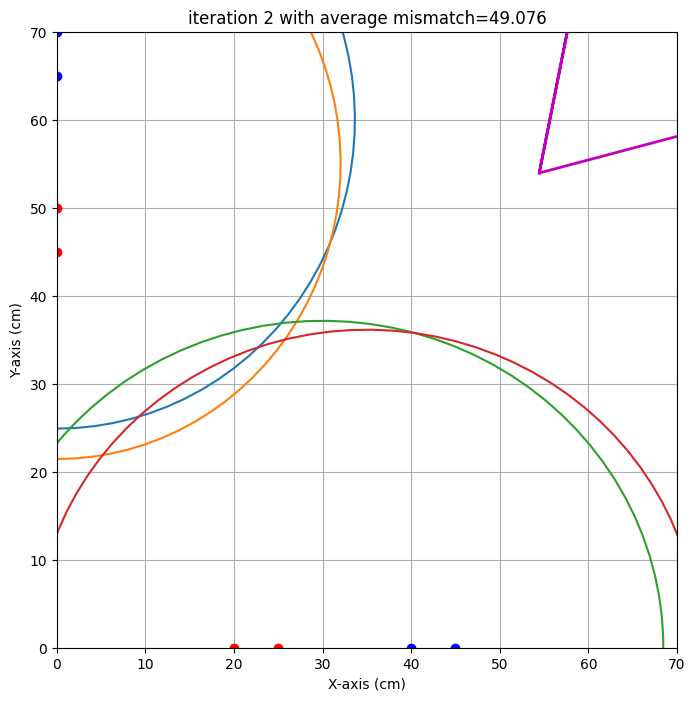

end iteration 2 with average mismatch=49.076


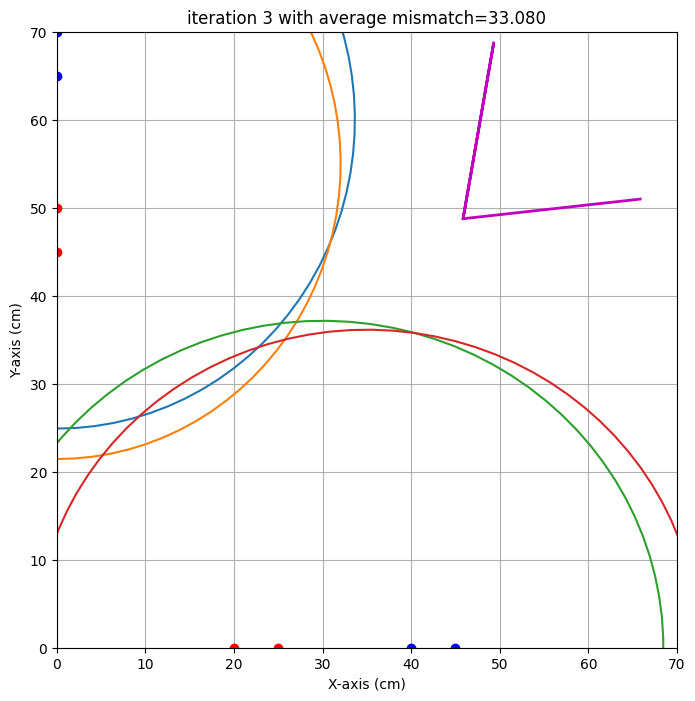

end iteration 3 with average mismatch=33.080


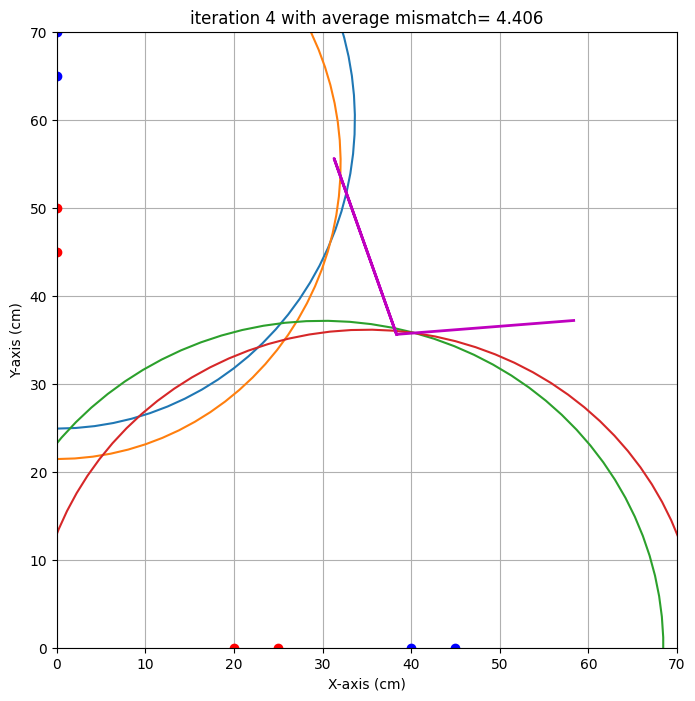

end iteration 4 with average mismatch= 4.406


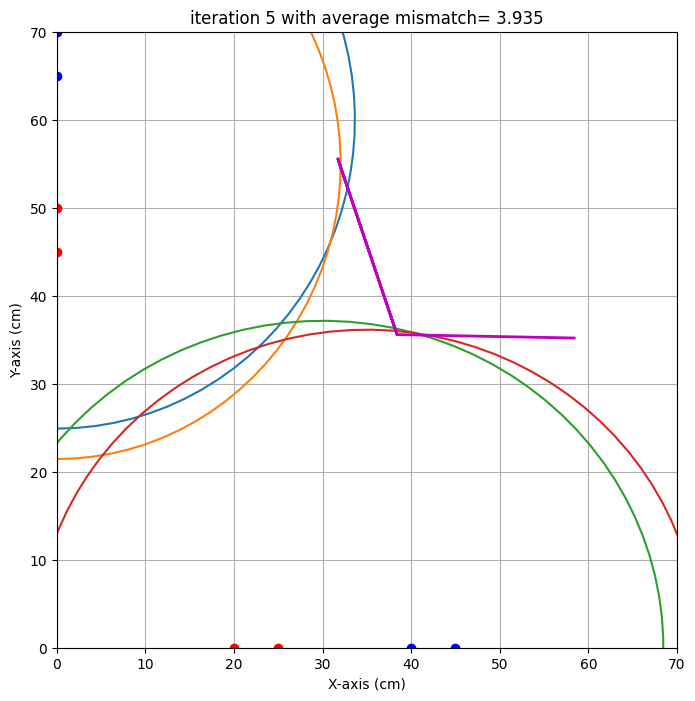

end iteration 5 with average mismatch= 3.935


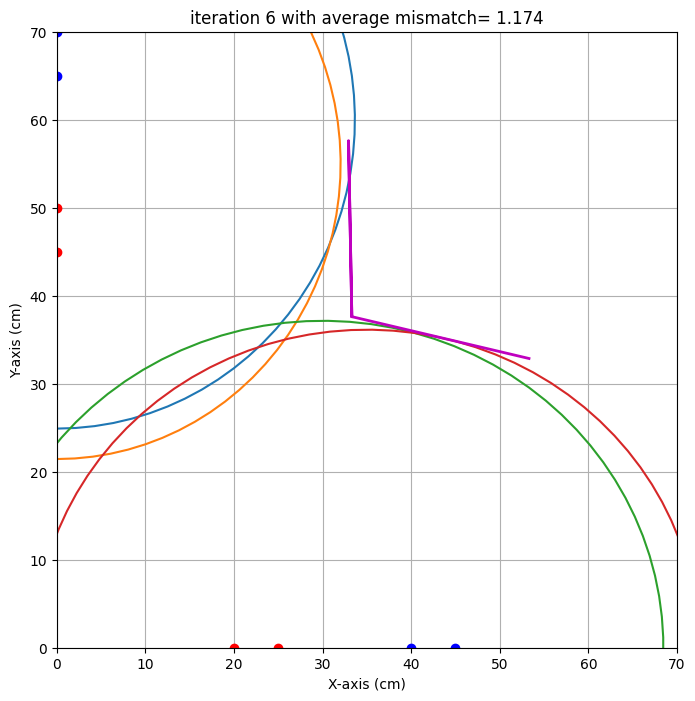

end iteration 6 with average mismatch= 1.174
end iteration 7 with average mismatch= 1.132


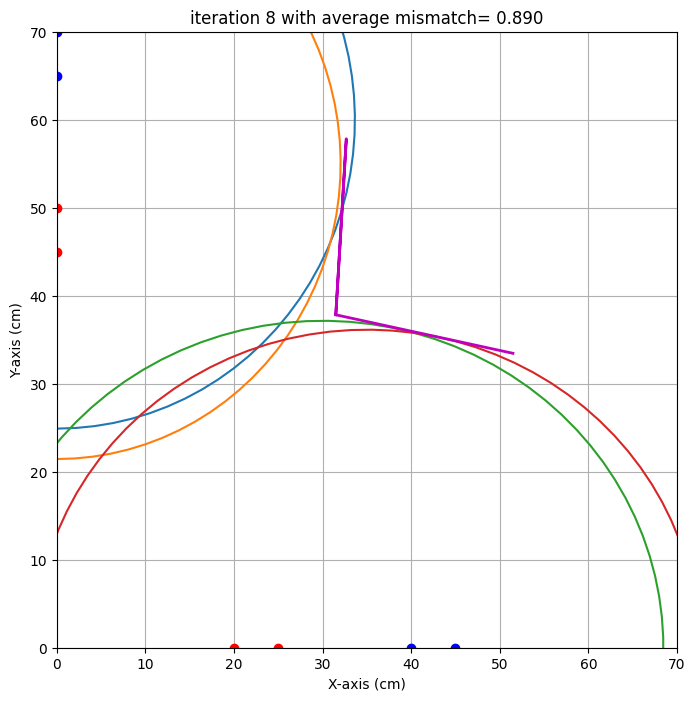

end iteration 8 with average mismatch= 0.890
end iteration 9 with average mismatch= 0.887
end iteration 10 with average mismatch= 0.835


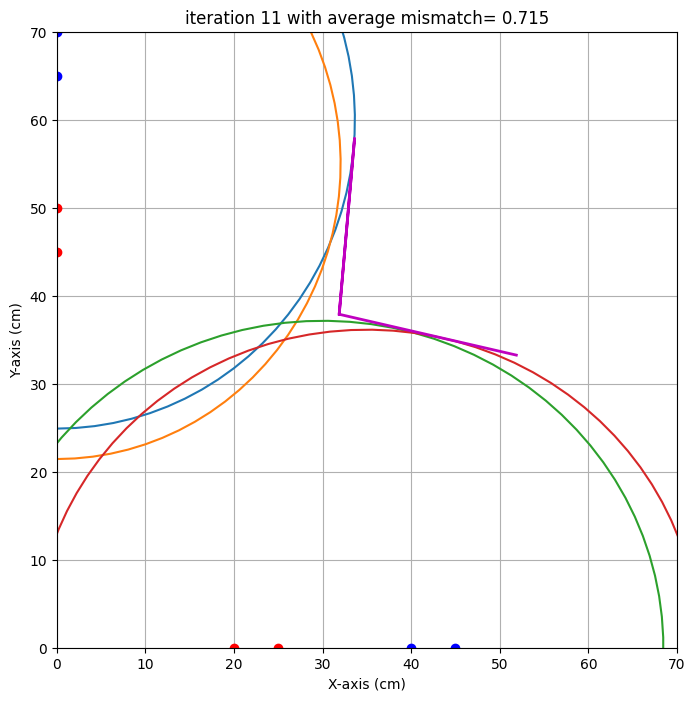

end iteration 11 with average mismatch= 0.715
end iteration 12 with average mismatch= 0.704
end iteration 13 with average mismatch= 0.704
end iteration 14 with average mismatch= 0.704
end iteration 15 with average mismatch= 0.704


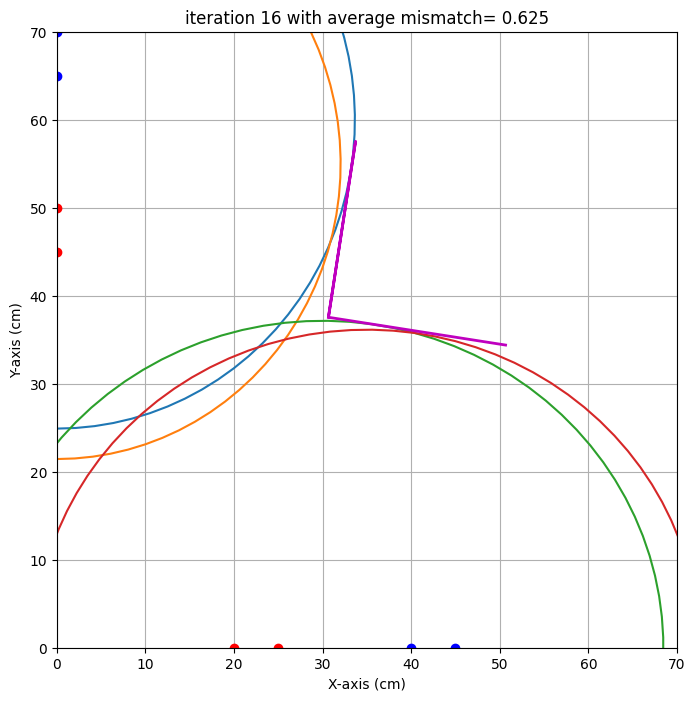

end iteration 16 with average mismatch= 0.625


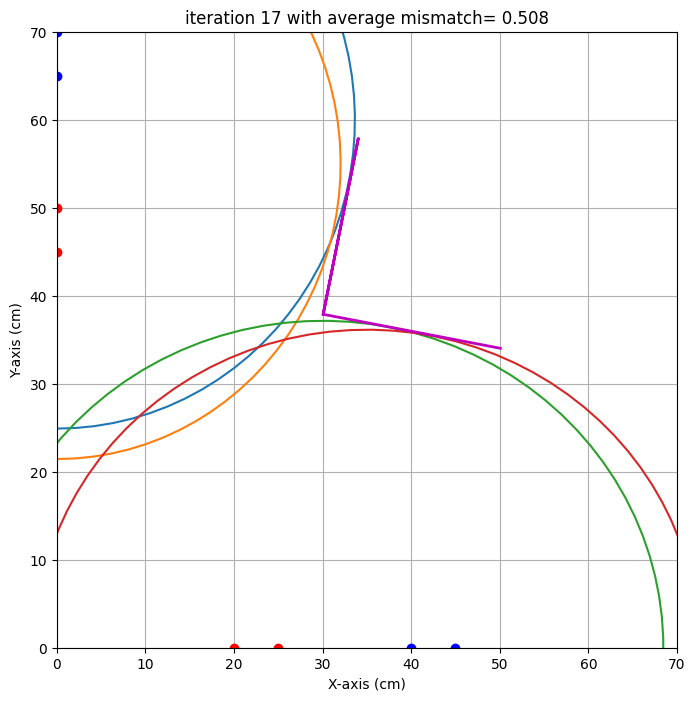

end iteration 17 with average mismatch= 0.508
end iteration 18 with average mismatch= 0.479
end iteration 19 with average mismatch= 0.475
end iteration 20 with average mismatch= 0.475
end iteration 21 with average mismatch= 0.475
end iteration 22 with average mismatch= 0.475
end iteration 23 with average mismatch= 0.454


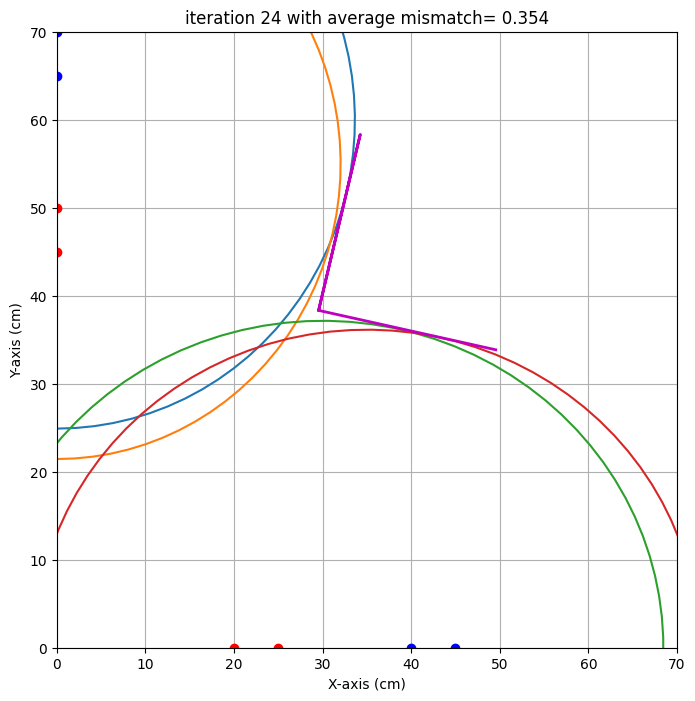

end iteration 24 with average mismatch= 0.354
end iteration 25 with average mismatch= 0.346
end iteration 26 with average mismatch= 0.345
end iteration 27 with average mismatch= 0.344


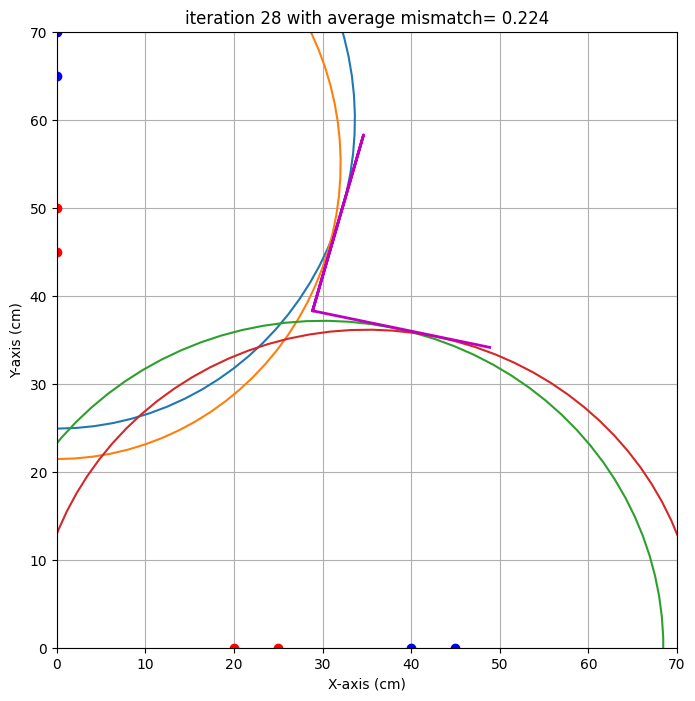

end iteration 28 with average mismatch= 0.224
end iteration 29 with average mismatch= 0.212
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.206
###############################################################################
end of iteration  30
Best alpha= -11.75 with uncertainty=   5.36
Best beta =  16.06 with uncertainty=   2.23
Best x0   =  28.86 with uncertainty=   0.87
Best y0   =  38.27 with uncertainty=   1.33
###############################################################################


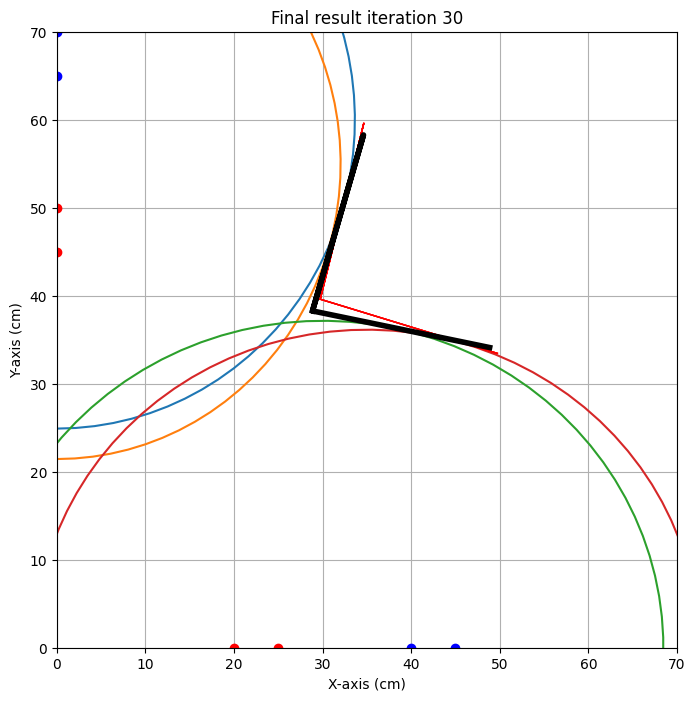

{'alpha': np.float64(-11.750374380907816), 'alpha_eps': np.float64(5.355532248537541), 'beta': np.float64(16.060665264941907), 'beta_eps': np.float64(2.2319586191970355), 'x0': np.float64(28.857513618113156), 'x0_eps': np.float64(0.8702555413208906), 'y0': np.float64(38.271409347408806), 'y0_eps': np.float64(1.3327643817657417)}
Adam Echant Hamdioui
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  70   0  50   0  70.00
1   0  50   0  30  72.60
2   0  40   0  20  77.34


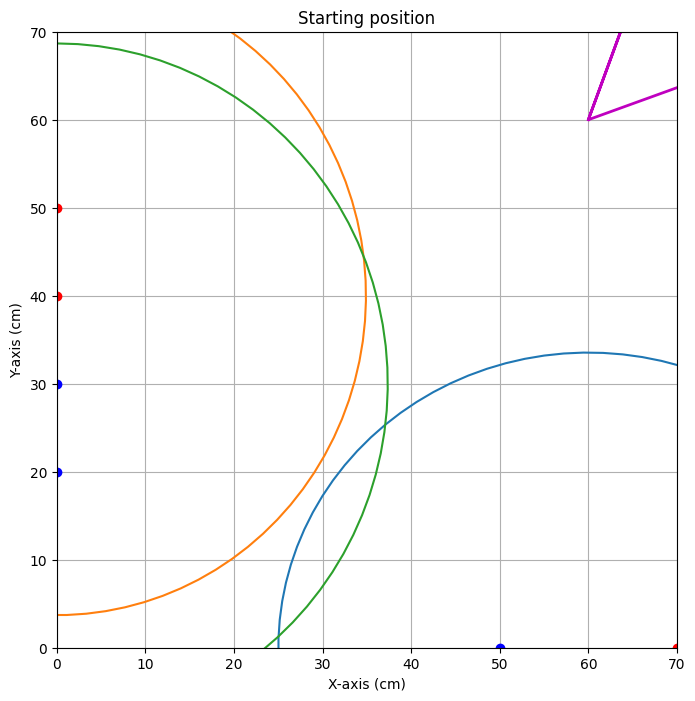


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=61.238


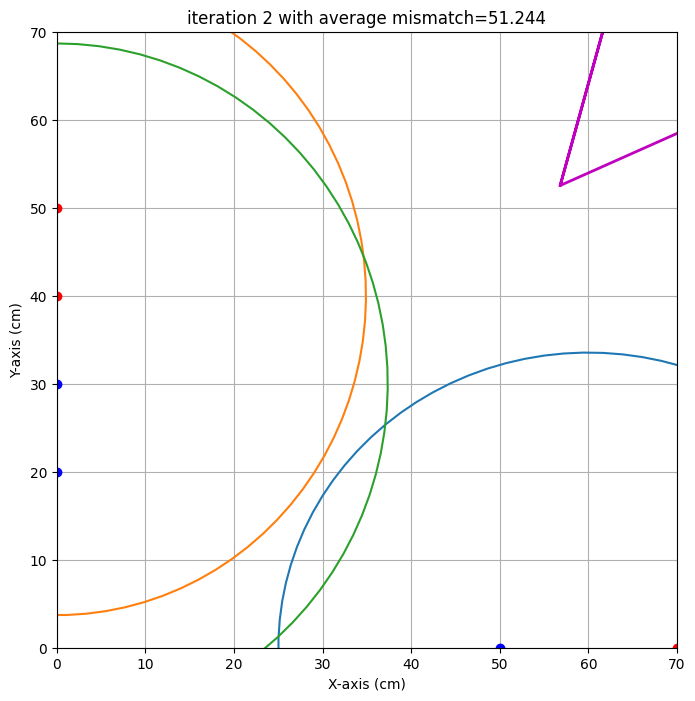

end iteration 2 with average mismatch=51.244


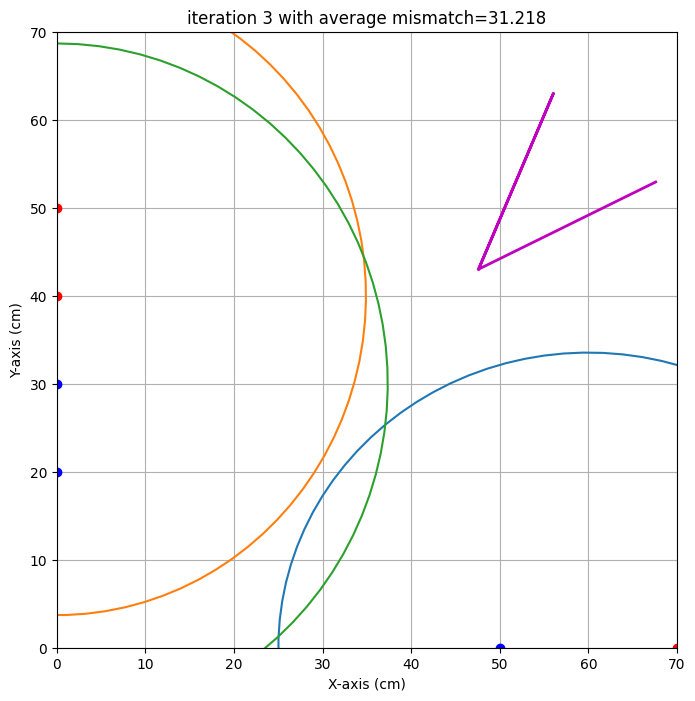

end iteration 3 with average mismatch=31.218


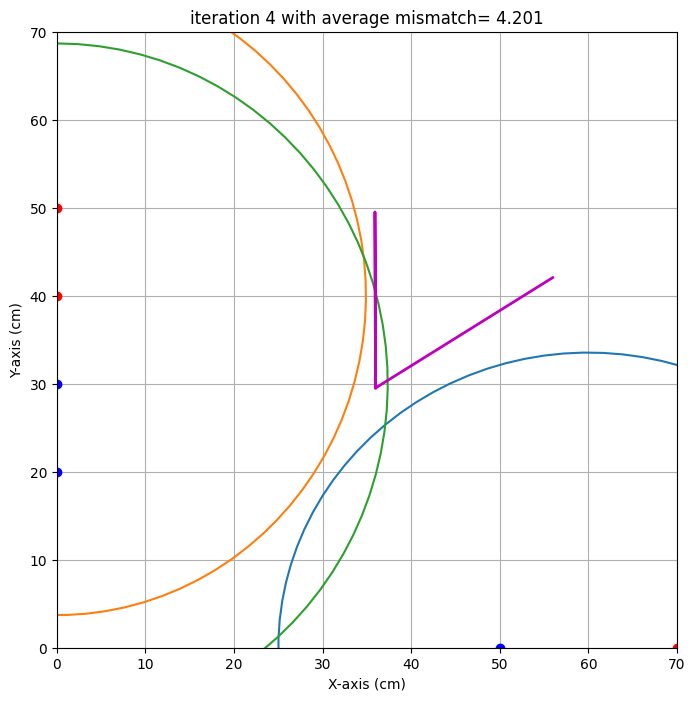

end iteration 4 with average mismatch= 4.201


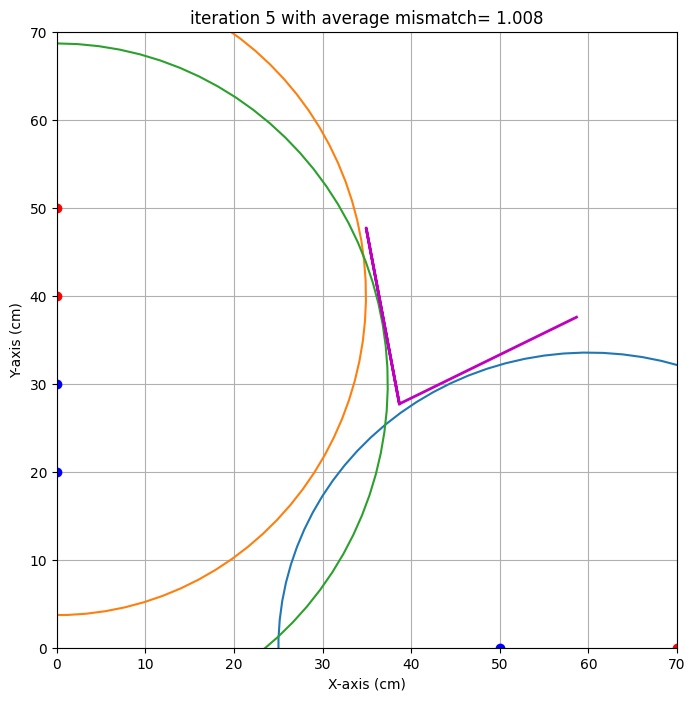

end iteration 5 with average mismatch= 1.008


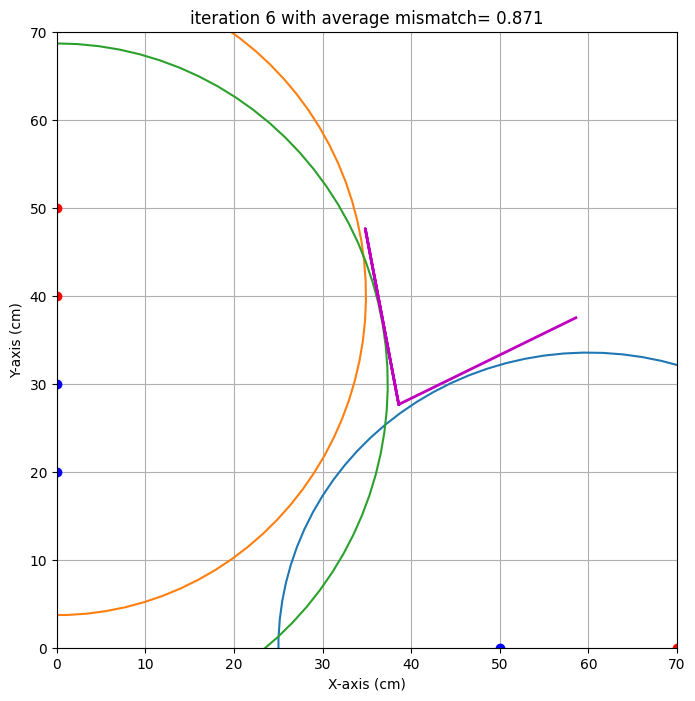

end iteration 6 with average mismatch= 0.871
end iteration 7 with average mismatch= 0.825
end iteration 8 with average mismatch= 0.774
end iteration 9 with average mismatch= 0.773
end iteration 10 with average mismatch= 0.773
end iteration 11 with average mismatch= 0.772
end iteration 12 with average mismatch= 0.772
end iteration 13 with average mismatch= 0.772
end iteration 14 with average mismatch= 0.772
end iteration 15 with average mismatch= 0.728


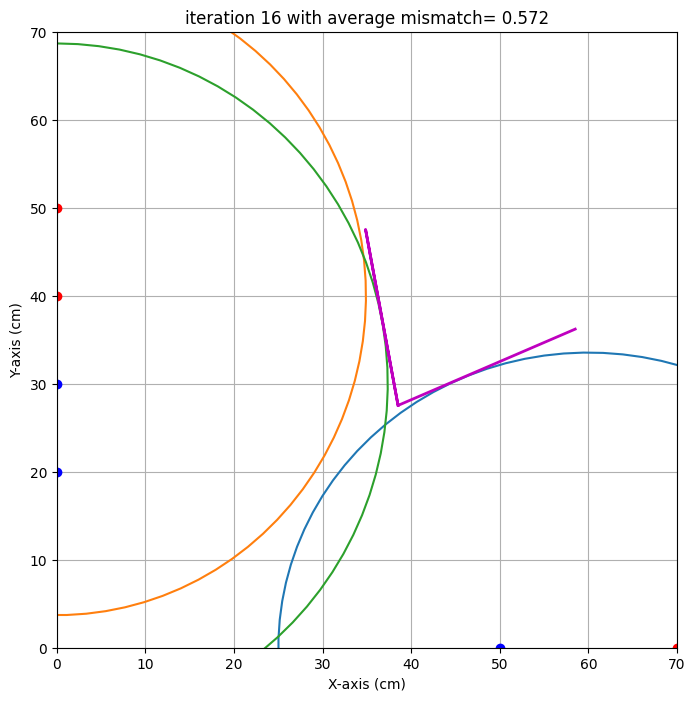

end iteration 16 with average mismatch= 0.572
end iteration 17 with average mismatch= 0.532
end iteration 18 with average mismatch= 0.522
end iteration 19 with average mismatch= 0.517
end iteration 20 with average mismatch= 0.516
end iteration 21 with average mismatch= 0.516
end iteration 22 with average mismatch= 0.516
end iteration 23 with average mismatch= 0.516
end iteration 24 with average mismatch= 0.516
end iteration 25 with average mismatch= 0.516
end iteration 26 with average mismatch= 0.516
end iteration 27 with average mismatch= 0.516
end iteration 28 with average mismatch= 0.516
end iteration 29 with average mismatch= 0.516
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.516
###############################################################################
end of iteration  30
Best alpha=  23.43 with uncertainty=  14.82
Best beta = -10.43 with uncertainty=   6.49
Best x0   = 

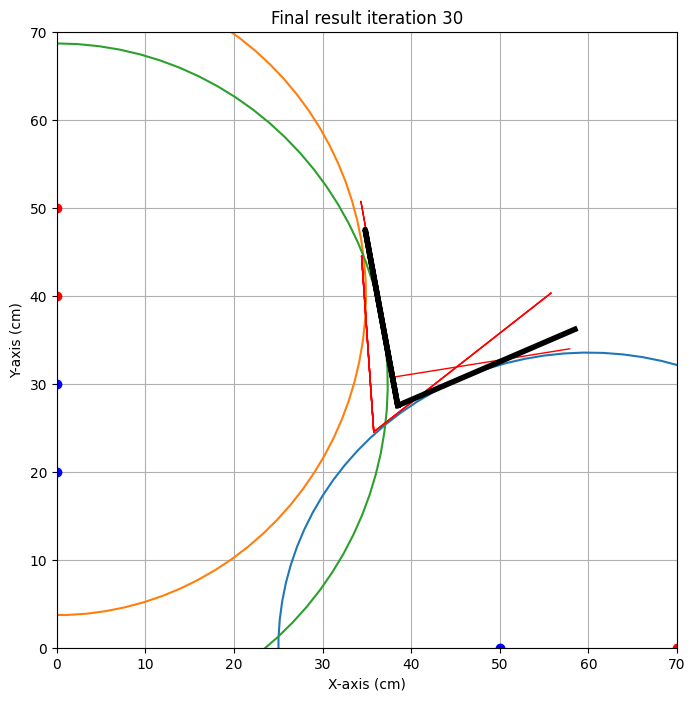

{'alpha': np.float64(23.426785213852376), 'alpha_eps': np.float64(14.815973466402532), 'beta': np.float64(-10.426186771669586), 'beta_eps': np.float64(6.494475829511496), 'x0': np.float64(38.4810323810487), 'x0_eps': np.float64(2.706814414149001), 'y0': np.float64(27.515171440716696), 'y0_eps': np.float64(3.218379344943603)}


In [20]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [21]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Bob Villerius 
x0 target is : 29.0. Gevonden waarde: 28.9 cm met een standaardafwijking van 0.9 cm 
y0 target is : 39.0. Gevonden waarde: 38.3 cm met een standaardafwijking van 1.3 cm 
alpha target is : -11.0. Gevonden waarde: -11.8 graden met een standaardafwijking van 5.4 graad 
beta target is : -19.0. Gevonden waarde: 16.1 graden met een standaardafwijking van 2.2 graad 

Adam Echant Hamdioui 
x0 target is : 29.0. Gevonden waarde: 38.5 cm met een standaardafwijking van 2.7 cm 
y0 target is : 39.0. Gevonden waarde: 27.5 cm met een standaardafwijking van 3.2 cm 
alpha target is : -11.0. Gevonden waarde: 23.4 graden met een standaardafwijking van 14.8 graad 
beta target is : -19.0. Gevonden waarde: -10.4 graden met een standaardafwijking van 6.5 graad 



## Opdracht 8: Iteratie1+. 14:48.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](Algorfinal.jpg)


In [22]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr    R
0  20   0  40   0  107
1  15   0  35   0  115
2   0  50   0  70   90
3   0  45   0  65   89


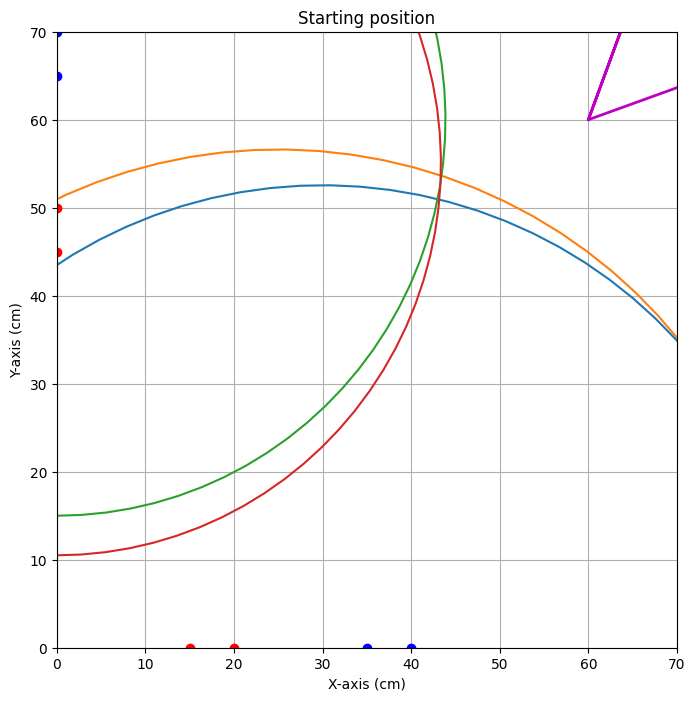


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=34.813


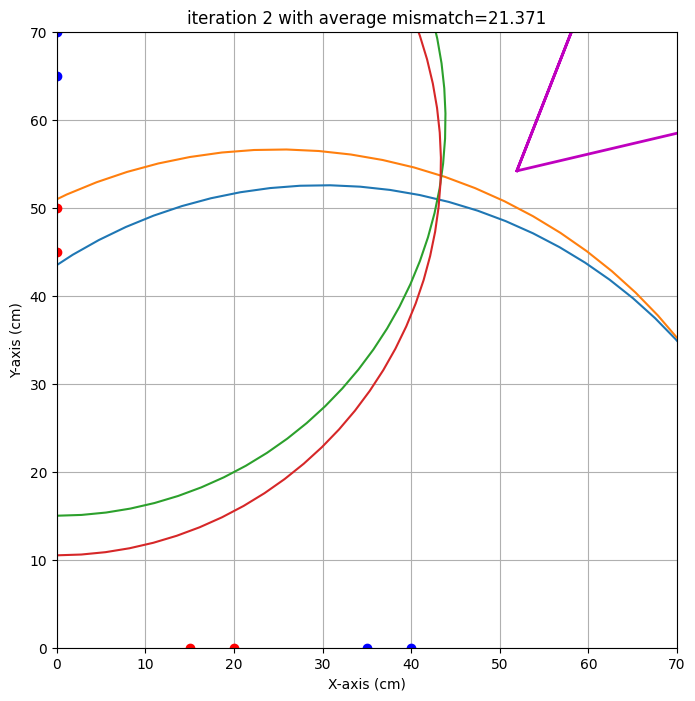

end iteration 2 with average mismatch=21.371


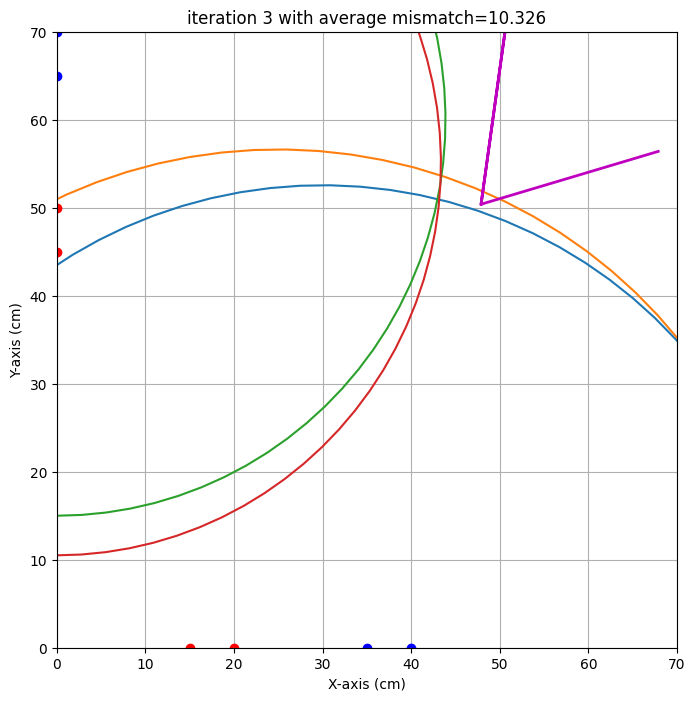

end iteration 3 with average mismatch=10.326


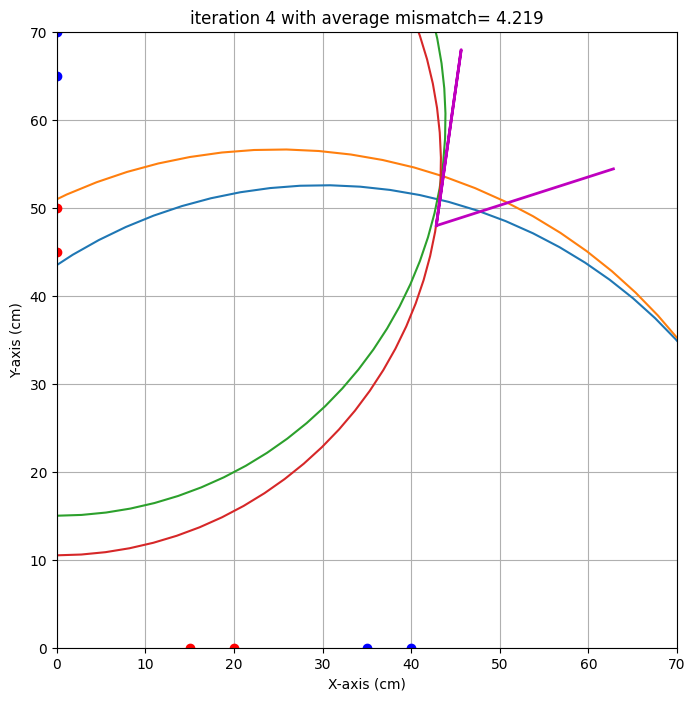

end iteration 4 with average mismatch= 4.219
end iteration 5 with average mismatch= 4.198
end iteration 6 with average mismatch= 4.198
end iteration 7 with average mismatch= 4.125


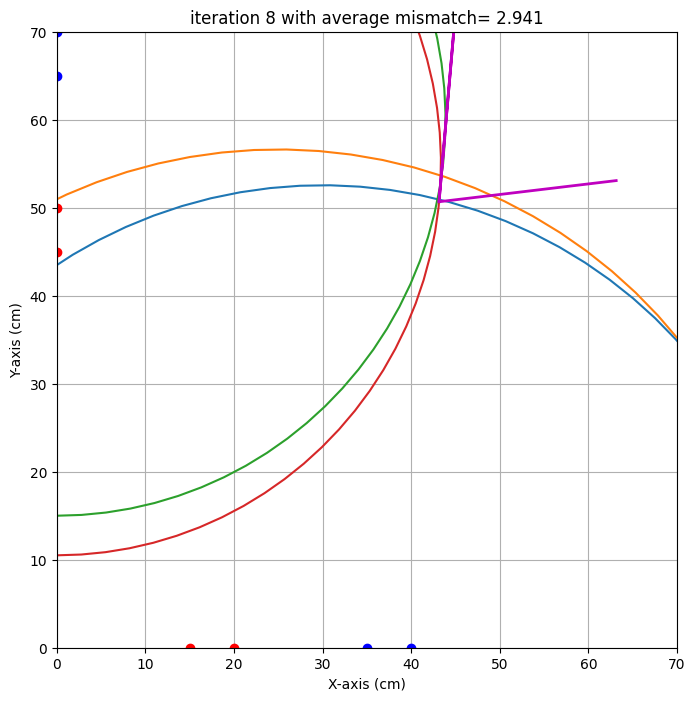

end iteration 8 with average mismatch= 2.941
end iteration 9 with average mismatch= 2.703
end iteration 10 with average mismatch= 2.703


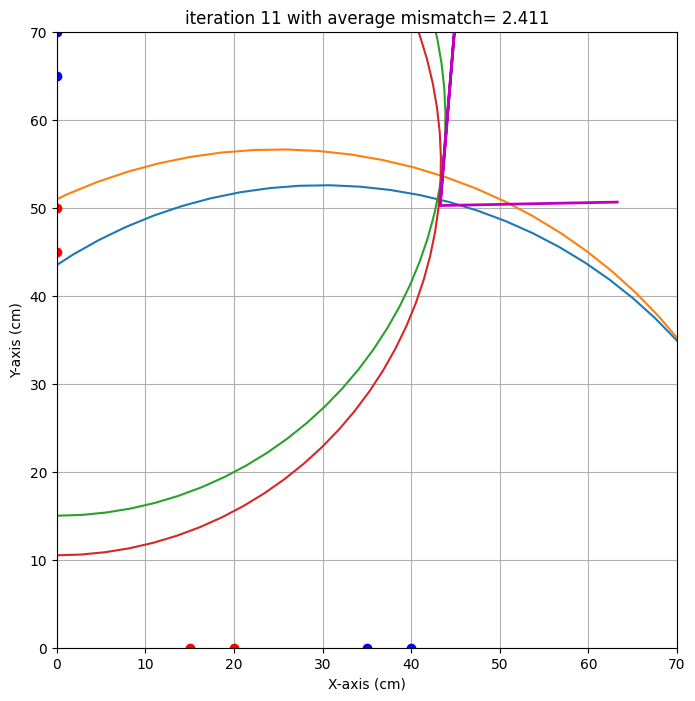

end iteration 11 with average mismatch= 2.411
end iteration 12 with average mismatch= 2.411


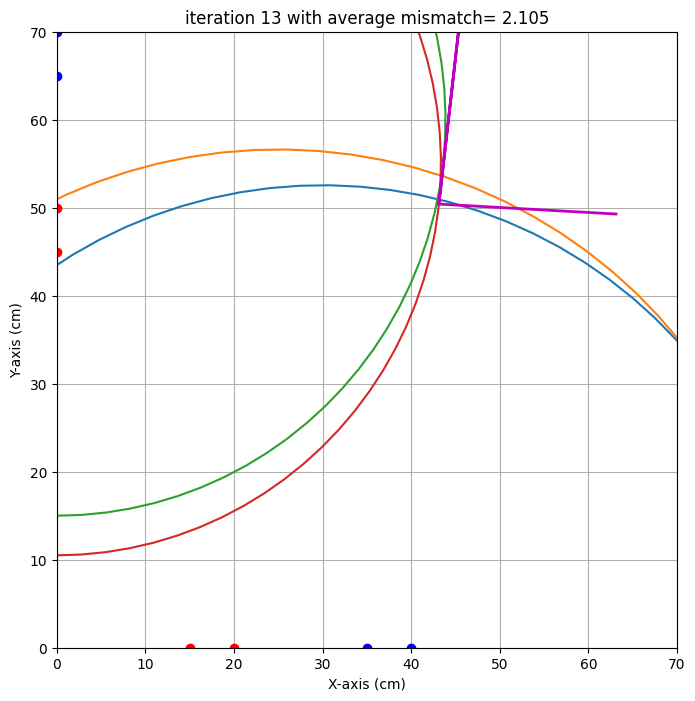

end iteration 13 with average mismatch= 2.105


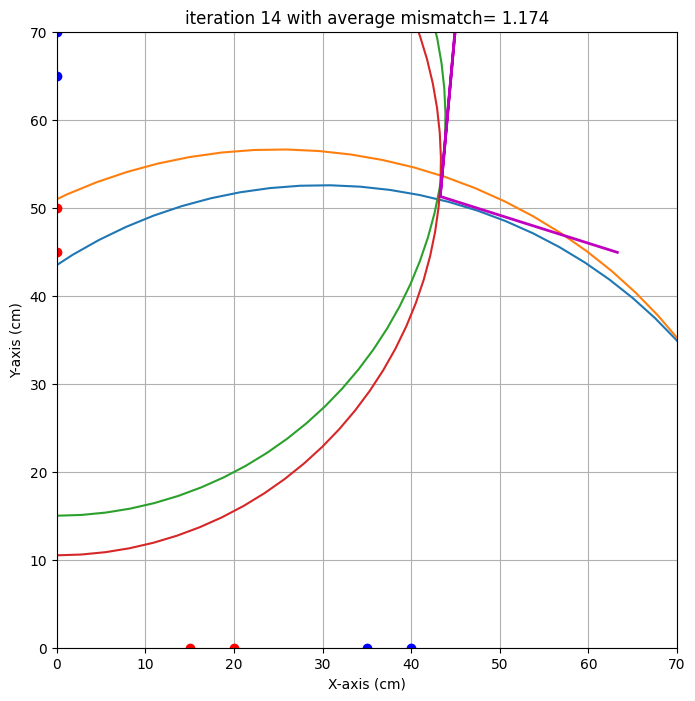

end iteration 14 with average mismatch= 1.174
end iteration 15 with average mismatch= 1.174
end iteration 16 with average mismatch= 1.124
end iteration 17 with average mismatch= 1.121
end iteration 18 with average mismatch= 1.120
end iteration 19 with average mismatch= 1.120
end iteration 20 with average mismatch= 1.120
end iteration 21 with average mismatch= 1.120
end iteration 22 with average mismatch= 1.120
end iteration 23 with average mismatch= 1.120
end iteration 24 with average mismatch= 1.120
end iteration 25 with average mismatch= 1.120
end iteration 26 with average mismatch= 1.120
end iteration 27 with average mismatch= 1.120
end iteration 28 with average mismatch= 1.120
end iteration 29 with average mismatch= 1.091
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 1.074
###############################################################################
end of iteration  30
Best alp

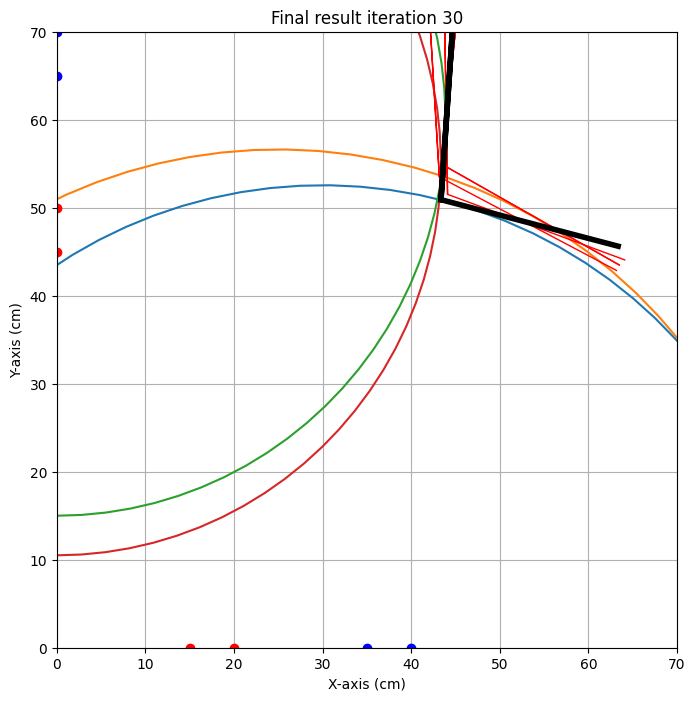

{'alpha': np.float64(-14.801455169985054), 'alpha_eps': np.float64(14.94074324588501), 'beta': np.float64(3.8469888047725016), 'beta_eps': np.float64(7.311492161266232), 'x0': np.float64(43.36505368437361), 'x0_eps': np.float64(0.7422274374030309), 'y0': np.float64(50.91251144288864), 'y0_eps': np.float64(4.010859866817505)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  50   0  70   0  83.50
1  45   0  65   0  81.90
2   0  50   0  70  72.50
3   0  45   0  65  70.75
4  35   0  55   0  77.70
5  40   0  60   0  80.20
6  30   0  50   0  76.26
7   0  35   0  55  66.72
8   0  40   0  60  68.52
9   0  30   0  50  67.77


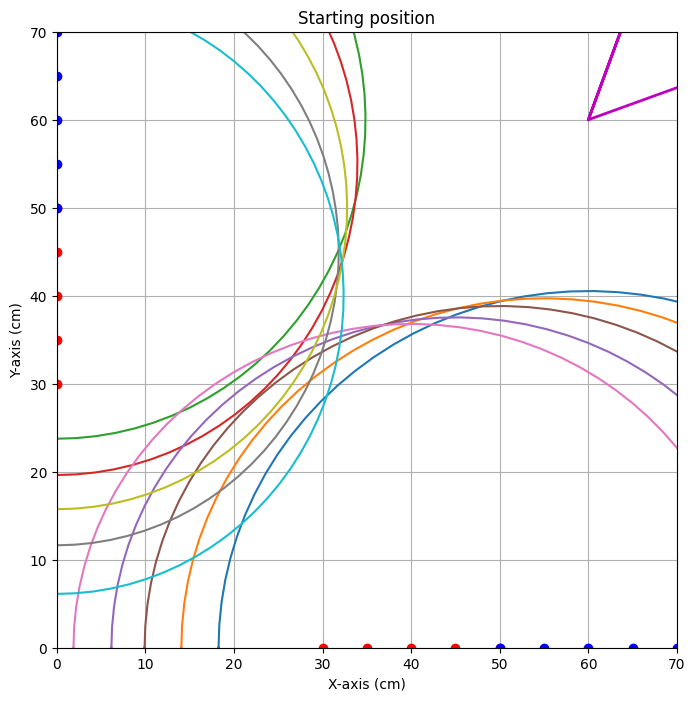


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=55.460


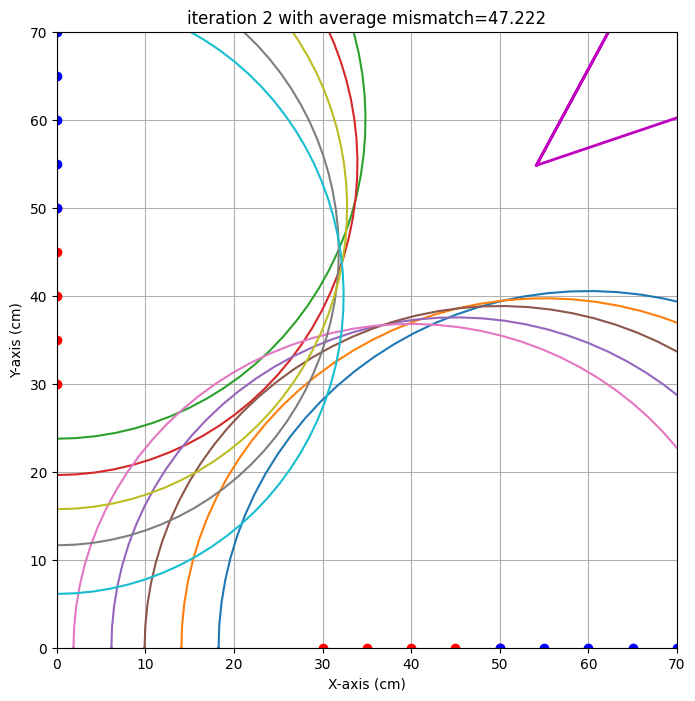

end iteration 2 with average mismatch=47.222


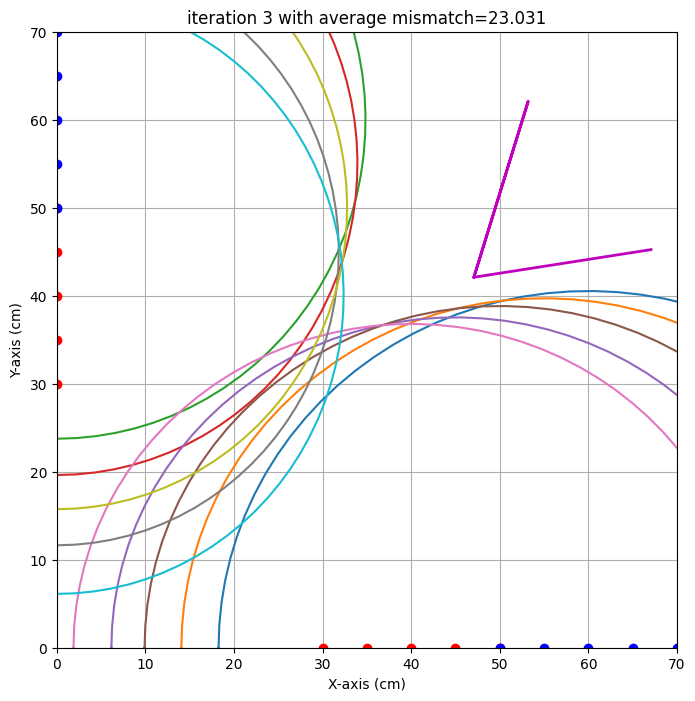

end iteration 3 with average mismatch=23.031


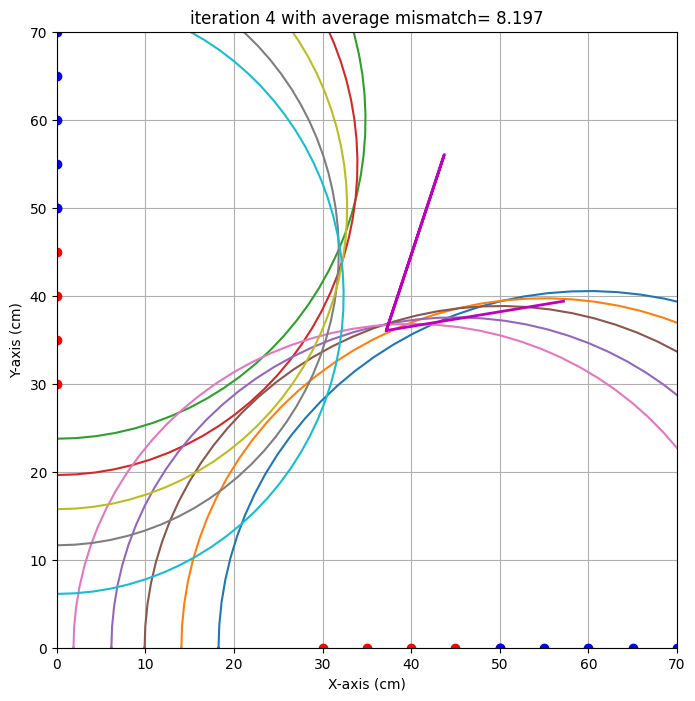

end iteration 4 with average mismatch= 8.197


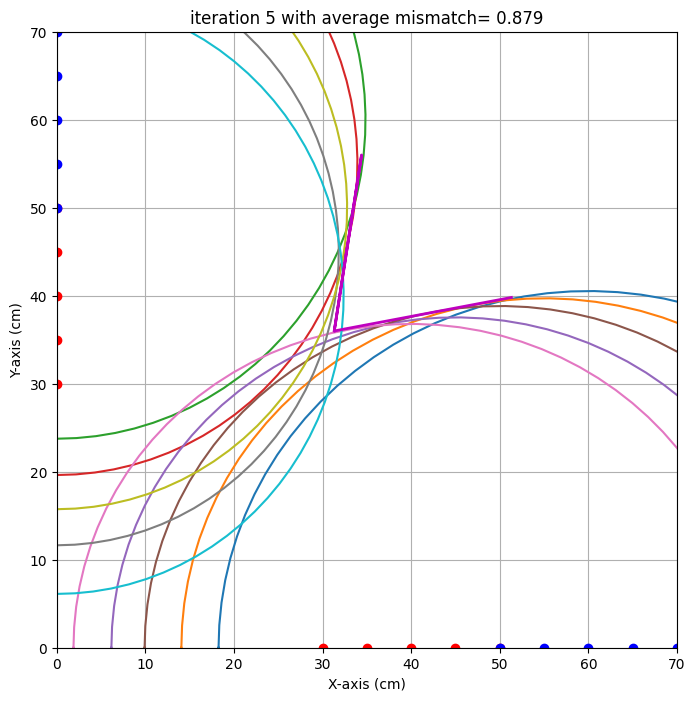

end iteration 5 with average mismatch= 0.879
end iteration 6 with average mismatch= 0.857
end iteration 7 with average mismatch= 0.830
end iteration 8 with average mismatch= 0.822
end iteration 9 with average mismatch= 0.770
end iteration 10 with average mismatch= 0.743
end iteration 11 with average mismatch= 0.731
end iteration 12 with average mismatch= 0.690
end iteration 13 with average mismatch= 0.689
end iteration 14 with average mismatch= 0.688
end iteration 15 with average mismatch= 0.688
end iteration 16 with average mismatch= 0.688
end iteration 17 with average mismatch= 0.688
end iteration 18 with average mismatch= 0.688
end iteration 19 with average mismatch= 0.688
end iteration 20 with average mismatch= 0.688
end iteration 21 with average mismatch= 0.688
end iteration 22 with average mismatch= 0.688
end iteration 23 with average mismatch= 0.688
end iteration 24 with average mismatch= 0.688
end iteration 25 with average mismatch= 0.688
end iteration 26 with average mismatch=

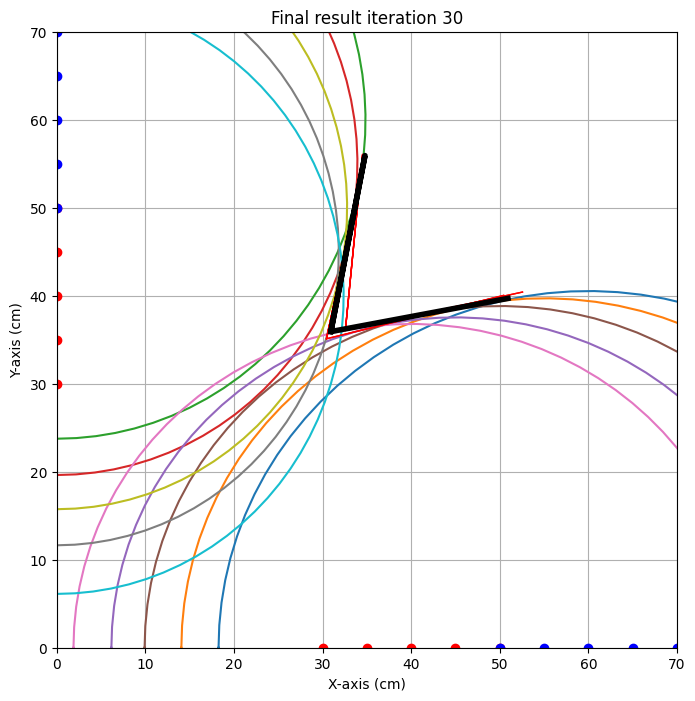

{'alpha': np.float64(10.677134720044517), 'alpha_eps': np.float64(3.168432993834738), 'beta': np.float64(10.90016406220186), 'beta_eps': np.float64(5.336329811963162), 'x0': np.float64(30.930087418196255), 'x0_eps': np.float64(1.6359727210692903), 'y0': np.float64(35.92470377628667), 'y0_eps': np.float64(0.8176809267999943)}
locatie 1 
x0 target is : 33.5. Gevonden waarde: 43.4 cm met een standaardafwijking van 0.7 cm 
y0 target is : 28.0. Gevonden waarde: 50.9 cm met een standaardafwijking van 4.0 cm 
alpha target is : 65.0. Gevonden waarde: -14.8 graden met een standaardafwijking van 14.9 graad 
beta target is : -51.0. Gevonden waarde: 3.8 graden met een standaardafwijking van 7.3 graad 

locatie 2 
x0 target is : 31.0. Gevonden waarde: 30.9 cm met een standaardafwijking van 1.6 cm 
y0 target is : 35.0. Gevonden waarde: 35.9 cm met een standaardafwijking van 0.8 cm 
alpha target is : 12.0. Gevonden waarde: 10.7 graden met een standaardafwijking van 3.2 graad 
beta target is : 10.0. G

In [23]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':33.5,#zelf aanvullen,
                    'y0':28,#zelf aanvullen,
                    'alpha' :65, #zelf aanvullen,
                    'beta' : -51#zelf aanvullen}, 
},
           'locatie 2':{'x0':31, #zelf aanvullen,
                    'y0':35, #zelf aanvullen,
                    'alpha' :12, #zelf aanvullen,
                    'beta' :10 #zelf aanvullen}
            }}
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[20,0,40,0,x],
    #[50,0,70,0,x],
    #[35,0,55,0,x]
    [20,0,40,0,107],
    #[25,0,45,0,x],
    [15,0,35,0,115],
    #[0,20,0,40,x],
    [0,50,0,70,90],
    [0,45,0,65,89]
    ])
    ,
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[20,0,40,0,x],
    [50,0,70,0,83.5],
    [45,0,65,0,81.9],
    #[0,20,0,40,x],
    [0,50,0,70,72.5],
    [0,45,0,65,70.75],
    [35,0,55,0,77.7],
    [40,0,60,0,80.2],
    [30,0,50,0, 76.26],
    [0,35,0,55,66.72],
    [0,40,0,60,68.52],
    [0,30,0,50,67.77]
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

In [24]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':  # zelf aanvullen,
                    'y0':  # zelf aanvullen,
                    'alpha' :  # zelf aanvullen,
                    'beta' :  # zelf aanvullen
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    # zelf aanvullen
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

SyntaxError: invalid syntax (1583240368.py, line 7)

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](tudelftLogo.png "Title")

Figuur: ![Alt](tudelftLogo.png "Title")

Figuur: ![Alt](tudelftLogo.png "Title")